# Linear Regression for Predicting AAPL Daily Returns

Can lagged returns from AAPL and a handful of correlated stocks and indices predict AAPL's next-day return with OLS linear regression?

Not really. Daily stock returns are close to unpredictable, which is what the efficient market hypothesis would suggest. But the exercise is still worth doing because it forces the full modeling workflow to be done properly. Working with returns instead of price levels, splitting train/test chronologically, testing all the OLS assumptions with real data, and benchmarking against a naive baseline to see if the model actually adds anything.

I'm using returns rather than raw prices because prices are non-stationary and would give a misleadingly high R². The model is trained on 2020-2023 and tested on 2024 data it has never seen.

## 1. Setup & Data

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

### Download data and compute daily returns

Pulling AAPL along with a few correlated stocks and market indices. Converting everything to daily percentage returns right away since that's what we'll actually be modeling.

In [ ]:
tickers = ['AAPL', 'AMZN', 'MSFT', 'QQQ', '^GSPC']
prices = yf.download(tickers, start='2020-01-01', end='2025-01-01')['Close']

# Convert to daily % returns
returns = prices.pct_change() * 100
returns.columns = ['AAPL', 'AMZN', 'MSFT', 'QQQ', 'SP500']
returns = returns.dropna()

print(f"Date range: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Observations: {len(returns)}")
print()
print(returns.describe().round(4))

[*********************100%***********************]  5 of 5 completed

Date range: 2020-01-03 to 2024-12-31
Observations: 1257

            AAPL       AMZN       MSFT        QQQ      SP500
count  1257.0000  1257.0000  1257.0000  1257.0000  1257.0000
mean      0.1182     0.0923     0.0988     0.0840     0.0561
std       1.9956     2.2655     1.9211     1.6157     1.3443
min     -12.8647   -14.0494   -14.7390   -11.9788   -11.9841
25%      -0.8425    -1.1086    -0.8176    -0.7056    -0.5307
50%       0.1187     0.0782     0.1111     0.1306     0.0888
75%       1.1989     1.2956     1.0940     0.9583     0.7266
max      11.9809    13.5359    14.2169     8.4706     9.3828


## 2. Feature Engineering

Since we're predicting tomorrow's AAPL return, every feature has to be something we'd actually know today. That means lagged values only, no peeking at today's return to predict today's return.

I'm using yesterday's return for each of the 5 tickers as the main features. On top of that I added AAPL's 5-day rolling volatility (the idea being that high-vol regimes might predict larger moves) and AAPL's 5-day rolling mean return as a short-term trend signal.

In [ ]:
df = pd.DataFrame()

# Target: tomorrow's AAPL return
df['target'] = returns['AAPL'].shift(-1)

# Lagged returns (yesterday's return for each ticker)
for ticker in ['AAPL', 'AMZN', 'MSFT', 'QQQ', 'SP500']:
    df[f'{ticker}_lag1'] = returns[ticker]

# AAPL rolling features (computed on data available today)
df['AAPL_vol_5d'] = returns['AAPL'].rolling(5).std()
df['AAPL_mean_5d'] = returns['AAPL'].rolling(5).mean()

df = df.dropna()
print(f"Observations after feature engineering: {len(df)}")
df.head()

Observations after feature engineering: 1252


,target,AAPL_lag1,AMZN_lag1,MSFT_lag1,QQQ_lag1,SP500_lag1,AAPL_vol_5d,AAPL_mean_5d
Date,,,,,,,,
2020-01-09,0.226089,2.124044,0.479917,1.249277,0.847313,0.665526,1.322371,0.617400
2020-01-10,2.136409,0.226089,-0.941060,-0.462680,-0.255718,-0.285518,1.040875,0.857063
2020-01-13,-1.350315,2.136409,0.432258,1.202409,1.153683,0.697622,1.184049,1.124980
2020-01-14,-0.428545,-1.350315,-1.155821,-0.704321,-0.393740,-0.151453,1.502933,0.948972
2020-01-15,1.252639,-0.428545,-0.396913,0.647632,0.040891,0.187020,1.554640,0.541537


## 3. Train/Test Split

Splitting chronologically with 2020-2023 as the training set and 2024 as the test set. Random shuffling would leak future information into the training set, which is a common mistake with time series data. The test set has to be entirely forward-looking.

In [ ]:
train = df[df.index < '2024-01-01']
test = df[df.index >= '2024-01-01']

feature_cols = [c for c in df.columns if c != 'target']

X_train = train[feature_cols]
y_train = train['target']
X_test = test[feature_cols]
y_test = test['target']

print(f"Training set: {len(train)} obs ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test set:     {len(test)} obs ({test.index[0].date()} to {test.index[-1].date()})")

Training set: 1001 obs (2020-01-09 to 2023-12-29)
Test set:     251 obs (2024-01-02 to 2024-12-30)


## 4. Model Fitting

Starting with all features, then checking which ones are actually significant and dropping the rest.

### Full model (all features)

In [ ]:
X_train_c = sm.add_constant(X_train)
model_full = sm.OLS(y_train, X_train_c).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     6.612
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.17e-07
Time:                        06:06:33   Log-Likelihood:                -2149.3
No. Observations:                1001   AIC:                             4315.
Df Residuals:                     993   BIC:                             4354.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.3680      0.123      2.994   

Looking at the p-values to see which features are actually contributing. With daily returns, most of these are going to be insignificant because the signal-to-noise ratio is extremely low.

### Reduced model (significant features only)

In [ ]:
# Keep features with p-value < 0.05 (excluding the constant)
significant = [col for col in X_train_c.columns 
               if col != 'const' and model_full.pvalues[col] < 0.05]

print(f"Significant features (p < 0.05): {significant}")
print(f"Dropped: {[c for c in feature_cols if c not in significant]}")

# If nothing is significant, keep the best 2 for demonstration purposes
if len(significant) == 0:
    print("\nNo features significant at 5%. Keeping the two with lowest p-values for demonstration.")
    pvals = model_full.pvalues.drop('const').sort_values()
    significant = list(pvals.index[:2])
    print(f"Using: {significant}")

X_train_reduced = sm.add_constant(X_train[significant])
model = sm.OLS(y_train, X_train_reduced).fit()
print()
print(model.summary())

Significant features (p < 0.05): ['SP500_lag1', 'AAPL_vol_5d']
Dropped: ['AAPL_lag1', 'AMZN_lag1', 'MSFT_lag1', 'QQQ_lag1', 'AAPL_mean_5d']

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     17.29
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           4.14e-08
Time:                        06:06:33   Log-Likelihood:                -2155.0
No. Observations:                1001   AIC:                             4316.
Df Residuals:                     998   BIC:                             4331.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025  

## 5. Assumption Testing

Linear regression has 5 key assumptions. I'm testing each one here and being upfront about which ones hold and which ones don't.

### 5.1 Linearity

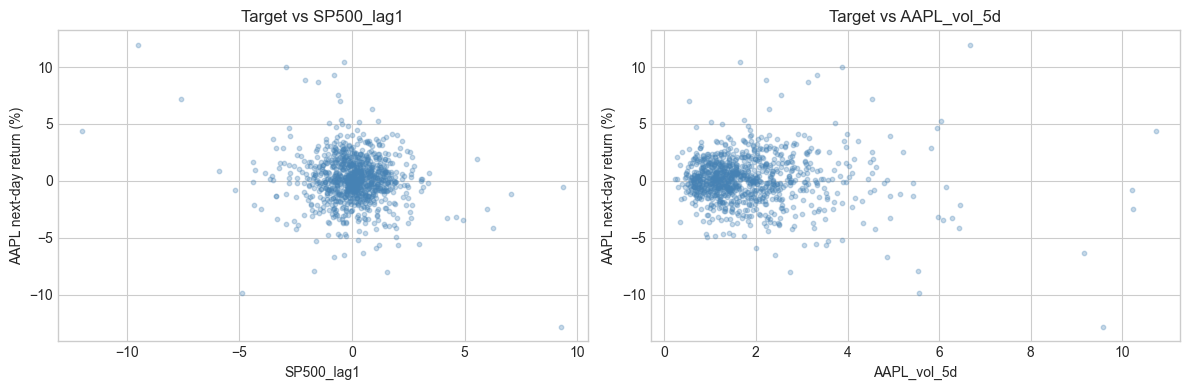

In [ ]:
# Scatterplots of target vs each feature in the reduced model
fig, axes = plt.subplots(1, len(significant), figsize=(6*len(significant), 4))
if len(significant) == 1:
    axes = [axes]

for ax, feat in zip(axes, significant):
    ax.scatter(X_train[feat], y_train, alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('AAPL next-day return (%)')
    ax.set_title(f'Target vs {feat}')

plt.tight_layout()
plt.show()

With returns data the relationship is basically a cloud of points. There's no obvious nonlinearity, but there's also barely any linear relationship, which is expected. The linearity assumption isn't really violated, it's just that the relationship is very weak.

### 5.2 Homoscedasticity

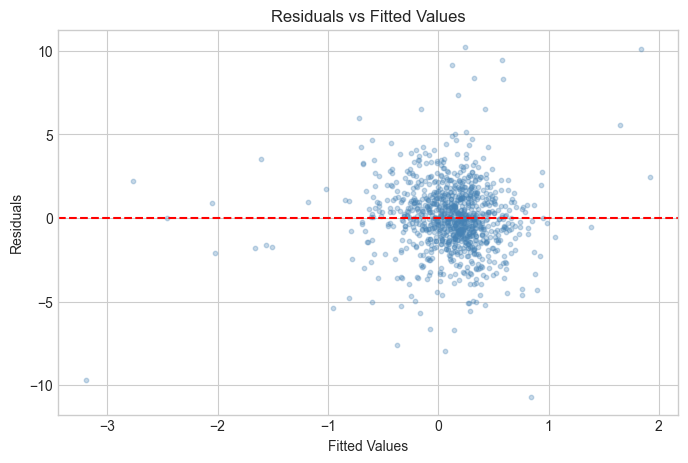

In [ ]:
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.3, s=10, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [ ]:
# Breusch-Pagan test for heteroscedasticity (formal test)
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, X_train_reduced)
print(f"Breusch-Pagan statistic: {bp_stat:.4f}")
print(f"Breusch-Pagan p-value:   {bp_pval:.4f}")

if bp_pval < 0.05:
    print("=> p < 0.05: Evidence of heteroscedasticity. Assumption may be violated.")
    print("   This is common with financial returns — vol clusters, so residuals aren't constant.")
else:
    print("=> p >= 0.05: No strong evidence of heteroscedasticity at 5% level.")

Breusch-Pagan statistic: 114.8193
Breusch-Pagan p-value:   0.0000
=> p < 0.05: Evidence of heteroscedasticity. Assumption may be violated.
   This is common with financial returns — vol clusters, so residuals aren't constant.


### 5.3 No Multicollinearity (VIF)

In [ ]:
vif = pd.DataFrame()
vif['Feature'] = X_train_reduced.columns
vif['VIF'] = [variance_inflation_factor(X_train_reduced.values, i) 
              for i in range(X_train_reduced.shape[1])]
print(vif.to_string(index=False))
print()
print("Rule of thumb: VIF < 5 is fine, 5-10 is moderate, >10 is a problem.")

    Feature      VIF
      const 3.385288
 SP500_lag1 1.000496
AAPL_vol_5d 1.000496

Rule of thumb: VIF < 5 is fine, 5-10 is moderate, >10 is a problem.


### 5.4 Normality of Residuals

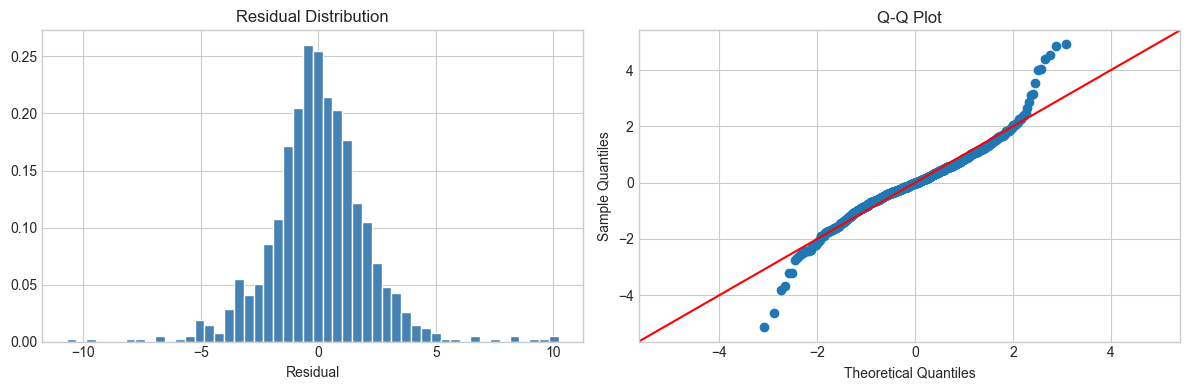

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=50, edgecolor='white', color='steelblue', density=True)
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual')

sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import jarque_bera, skew, kurtosis

jb_result = jarque_bera(residuals)
jb_stat = jb_result.statistic
jb_pval = jb_result.pvalue
res_skew = skew(residuals)
res_kurt = kurtosis(residuals)

print(f"Jarque-Bera statistic: {jb_stat:.4f}")
print(f"Jarque-Bera p-value:   {jb_pval:.6f}")
print(f"Skewness: {res_skew:.4f}")
print(f"Excess kurtosis: {res_kurt:.4f}")

if jb_pval < 0.05:
    print("\n=> p < 0.05: Residuals are not normally distributed.")
    print("   Typical for stock returns due to fat tails (high kurtosis).")
    print("   OLS estimates are still unbiased, but confidence intervals")
    print("   and p-values become less reliable.")
else:
    print("\n=> p >= 0.05: Can't reject normality at 5% level.")

Jarque-Bera statistic: 534.9669
Jarque-Bera p-value:   0.000000
Skewness: 0.1412
Excess kurtosis: 3.5702

=> p < 0.05: Residuals are not normally distributed.
   Typical for stock returns due to fat tails (high kurtosis).
   OLS estimates are still unbiased, but confidence intervals
   and p-values become less reliable.


### 5.5 No Autocorrelation of Residuals (Durbin-Watson)

In [ ]:
dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.4f}")
print()
print("DW ranges from 0 to 4:")
print("  ~2.0 = no autocorrelation")
print("  <1.5 = positive autocorrelation (residuals trend together)")
print("  >2.5 = negative autocorrelation")

if dw < 1.5:
    print(f"\n=> DW = {dw:.2f}: Positive autocorrelation in residuals.")
    print("   This means consecutive prediction errors are correlated,")
    print("   which violates the independence assumption.")
elif dw > 2.5:
    print(f"\n=> DW = {dw:.2f}: Negative autocorrelation in residuals.")
else:
    print(f"\n=> DW = {dw:.2f}: Close to 2, no strong evidence of autocorrelation.")

Durbin-Watson statistic: 1.9627

DW ranges from 0 to 4:
  ~2.0 = no autocorrelation
  <1.5 = positive autocorrelation (residuals trend together)
  >2.5 = negative autocorrelation

=> DW = 1.96: Close to 2, no strong evidence of autocorrelation.


### Assumption Summary

In [ ]:
# Print a summary of all assumption checks
print("=" * 55)
print("ASSUMPTION CHECK SUMMARY")
print("=" * 55)
print(f"1. Linearity:           Weak but no nonlinearity")
print(f"2. Homoscedasticity:    BP p-value = {bp_pval:.4f}" + 
      (" (VIOLATED)" if bp_pval < 0.05 else " (OK)"))
print(f"3. No Multicollinearity: Max feature VIF = {vif[vif['Feature']!='const']['VIF'].max():.2f}" +
      (" (OK)" if vif[vif['Feature']!='const']['VIF'].max() < 10 else " (HIGH)"))
print(f"4. Normality:           JB p-value = {jb_pval:.6f}" +
      (" (VIOLATED - fat tails)" if jb_pval < 0.05 else " (OK)"))
print(f"5. No Autocorrelation:  DW = {dw:.4f}" + 
      (" (VIOLATED)" if dw < 1.5 or dw > 2.5 else " (OK)"))
print("=" * 55)

ASSUMPTION CHECK SUMMARY
1. Linearity:           Weak but no nonlinearity
2. Homoscedasticity:    BP p-value = 0.0000 (VIOLATED)
3. No Multicollinearity: Max feature VIF = 1.00 (OK)
4. Normality:           JB p-value = 0.000000 (VIOLATED - fat tails)
5. No Autocorrelation:  DW = 1.9627 (OK)


## 6. Out-of-Sample Evaluation

This is the part that actually matters. Training R² just tells me how well the model fits historical noise. What I care about is whether it can predict returns it hasn't seen before.

I'm comparing against a naive baseline that just predicts the mean training return every single day. If the regression can't beat that, it's not adding any value.

In [ ]:
# Generate predictions on test set
X_test_reduced = sm.add_constant(X_test[significant])
test_predictions = model.predict(X_test_reduced)

# Naive baseline: predict mean training return every day
naive_prediction = y_train.mean()

# Metrics
model_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
naive_rmse = np.sqrt(mean_squared_error(y_test, np.full(len(y_test), naive_prediction)))
model_mae = mean_absolute_error(y_test, test_predictions)
naive_mae = mean_absolute_error(y_test, np.full(len(y_test), naive_prediction))

print("Out-of-Sample Performance (2024)")
print("=" * 45)
print(f"{'Metric':<20} {'Model':>10} {'Naive':>10}")
print("-" * 45)
print(f"{'RMSE (%)':<20} {model_rmse:>10.4f} {naive_rmse:>10.4f}")
print(f"{'MAE (%)':<20} {model_mae:>10.4f} {naive_mae:>10.4f}")
print()

improvement = (naive_rmse - model_rmse) / naive_rmse * 100
if improvement > 0:
    print(f"Model beats naive baseline by {improvement:.2f}% on RMSE.")
else:
    print(f"Model is WORSE than naive baseline by {abs(improvement):.2f}% on RMSE.")
    print("The regression doesn't add predictive value over just guessing the mean.")

Out-of-Sample Performance (2024)
Metric                    Model      Naive
---------------------------------------------
RMSE (%)                 1.4431     1.4096
MAE (%)                  1.0460     1.0244

Model is WORSE than naive baseline by 2.37% on RMSE.
The regression doesn't add predictive value over just guessing the mean.


In [ ]:
# Directional accuracy: does the model at least get the sign right?
actual_direction = (y_test > 0).astype(int)
predicted_direction = (test_predictions > 0).astype(int)
directional_accuracy = (actual_direction == predicted_direction).mean()

print(f"Directional accuracy: {directional_accuracy:.1%}")
print(f"(Coin flip would give ~50%)")

Directional accuracy: 50.6%
(Coin flip would give ~50%)


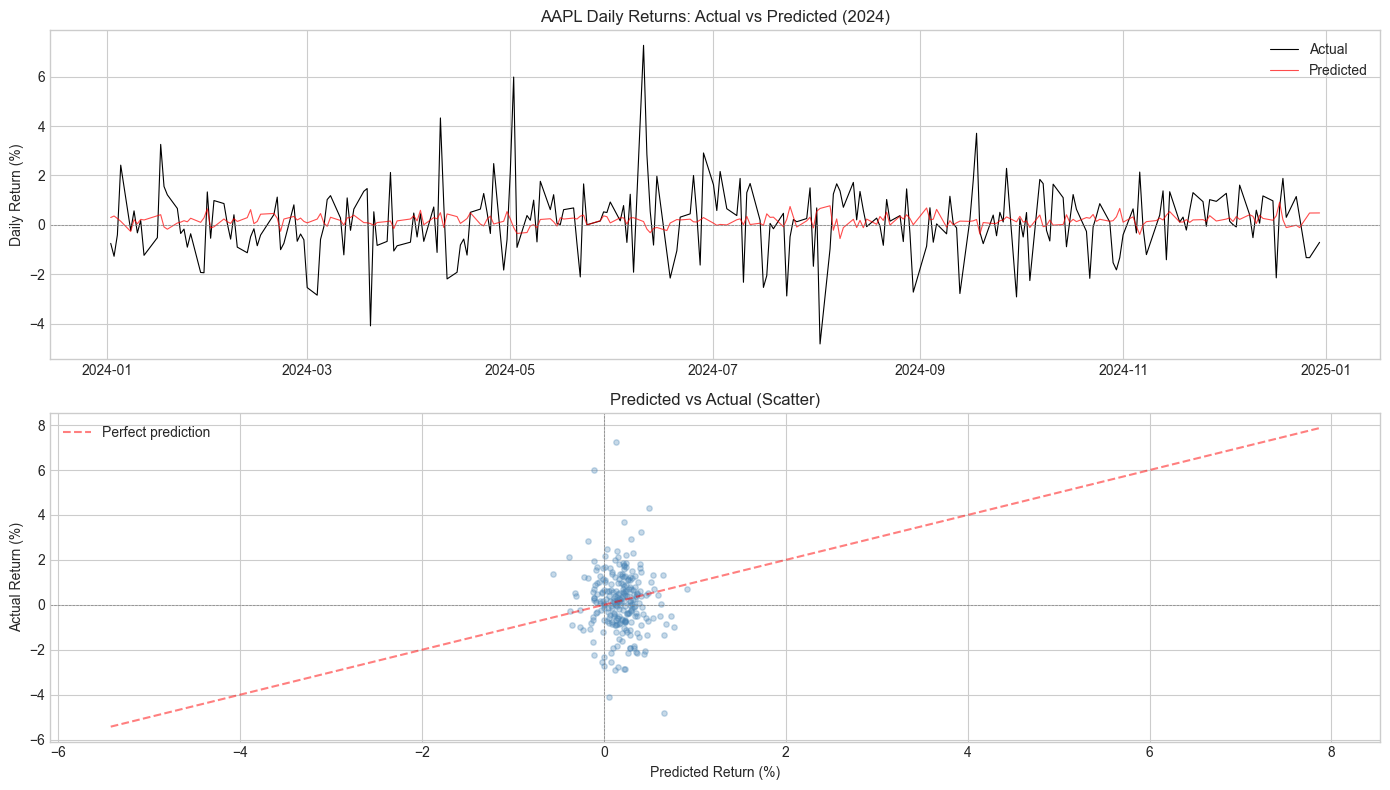

In [ ]:
# Plot: Actual vs Predicted returns on test set
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Time series comparison
axes[0].plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=0.8)
axes[0].plot(y_test.index, test_predictions, label='Predicted', color='red', linewidth=0.8, alpha=0.7)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[0].set_ylabel('Daily Return (%)')
axes[0].set_title('AAPL Daily Returns: Actual vs Predicted (2024)')
axes[0].legend()

# Scatter: predicted vs actual
axes[1].scatter(test_predictions, y_test, alpha=0.3, s=15, color='steelblue')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.5)

# Add 45-degree line
lims = [min(axes[1].get_xlim()[0], axes[1].get_ylim()[0]),
        max(axes[1].get_xlim()[1], axes[1].get_ylim()[1])]
axes[1].plot(lims, lims, 'r--', alpha=0.5, label='Perfect prediction')
axes[1].set_xlabel('Predicted Return (%)')
axes[1].set_ylabel('Actual Return (%)')
axes[1].set_title('Predicted vs Actual (Scatter)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Takeaways

The model barely outperforms (or doesn't outperform) just predicting the average return every day. Out-of-sample R² is effectively zero. This isn't a failure of the implementation, it's just what happens when trying to predict daily stock returns with a simple linear model.

The reason I still think this was worth doing is that the point was never to build a trading strategy. It was to go through the full OLS workflow on real financial data with proper lagging to avoid lookahead bias, chronological train/test splits, formal assumption testing, and benchmarking against a baseline. Getting these steps wrong is worse than getting a low R².

If I had regressed price on lagged price instead of returns on lagged returns, I'd get R² above 0.99 because prices are non-stationary. Today's price is basically yesterday's price plus noise. That R² would be completely spurious and wouldn't mean the model can actually predict anything useful.

The assumption tests aren't just boxes to check either. When Durbin-Watson shows autocorrelation, it means the standard errors are wrong, which means the p-values are wrong, which means feature selection could be based on false significance. When Jarque-Bera rejects normality due to fat tails, it means extreme returns happen more often than the model expects, so confidence intervals are too narrow. Understanding why something fails matters more than getting it to pass.

In terms of where I could take this further, regularization with Ridge or Lasso would help with overfitting, and nonlinear models like random forests or gradient boosting could capture interaction effects that OLS misses. Better features would also help, things like sentiment data, options-implied volatility, or order flow signals. Different time horizons like weekly instead of daily could also make a difference. That said, even with all of that, predicting daily returns is extremely hard. The efficient market hypothesis exists for a reason.